In [2]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
zip_path = "chest_xray.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall()

print("Dataset extracted")

Dataset extracted


In [4]:
import os

dataset_path = "chest_xray"

total_images = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            total_images += 1

print("Total images:", total_images)

Total images: 20771


In [5]:
import os

dataset_path = "chest_xray"

for root, dirs, files in os.walk(dataset_path):
    images = [f for f in files if f.endswith(('.jpg','.jpeg','.png'))]
    
    if len(images) > 0:
        print(root, ":", len(images))

chest_xray\test\NORMAL : 1159
chest_xray\test\NORMAL\.ipynb_checkpoints : 1
chest_xray\test\PNEUMONIA : 970
chest_xray\train\NORMAL : 8604
chest_xray\train\NORMAL\.ipynb_checkpoints : 1
chest_xray\train\PNEUMONIA : 8549
chest_xray\train\PNEUMONIA\.ipynb_checkpoints : 1
chest_xray\val\NORMAL : 908
chest_xray\val\PNEUMONIA : 578


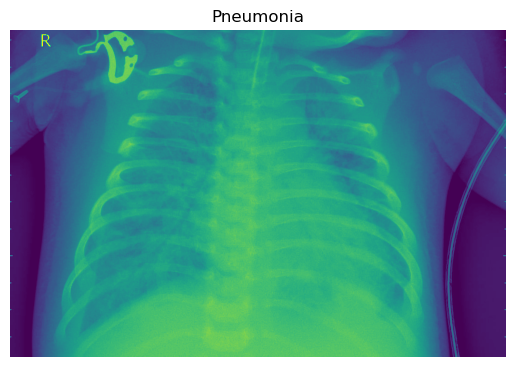

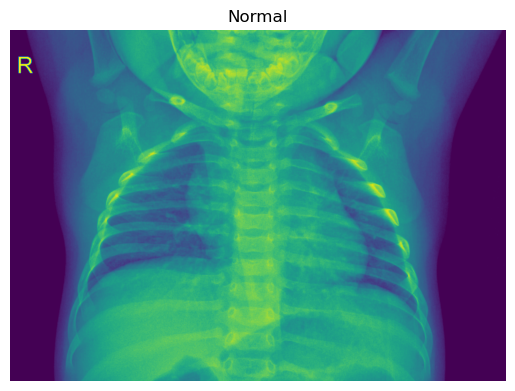

In [6]:
image = Image.open("./chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg")
plt.imshow(image)
plt.title("Pneumonia")
plt.axis("off")
plt.show()

image_normal = Image.open("./chest_xray/train/NORMAL/IM-0280-0001.jpeg")
plt.imshow(image_normal)
plt.title("Normal")
plt.axis("off")
plt.show()

In [7]:
training_dir = "./chest_xray/train/"
valid_dir = "./chest_xray/val/"
test_dir = "./chest_xray/test/"

In [8]:
training_generator = ImageDataGenerator(
    rescale=1/255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [9]:
data_train = training_generator.flow_from_directory(
    training_dir,
    target_size=(224,224),
    batch_size=8,
    class_mode="binary"
)

Found 17155 images belonging to 2 classes.


In [10]:
validation_generator = ImageDataGenerator(rescale=1/255)

data_valid = validation_generator.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=8,
    class_mode="binary"
)

Found 1486 images belonging to 2 classes.


In [11]:
test_generator = ImageDataGenerator(rescale=1/255)

data_test = test_generator.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=8,
    class_mode="binary"
)

Found 2130 images belonging to 2 classes.


In [12]:
from tensorflow.keras.applications import DenseNet121

In [13]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [14]:
for layer in base_model.layers:
    layer.trainable = False

In [16]:
x = base_model.output

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,301,185 (27.85 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
    ]
)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    data_train,
    epochs=20,
    validation_data=data_valid,
    callbacks=[early_stop]
)

c:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 2442s 1s/step - accuracy: 0.8342 - auc: 0.9159 - loss: 0.3830 - precision: 0.8302 - recall: 0.8389 - val_accuracy: 0.8930 - val_auc: 0.9634 - val_loss: 0.2375 - val_precision: 0.8872 - val_recall: 0.8304
Epoch 2/20
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 10378s 5s/step - accuracy: 0.8601 - auc: 0.9366 - loss: 0.3280 - precision: 0.8596 - recall: 0.8598 - val_accuracy: 0.8950 - val_auc: 0.9695 - val_loss: 0.2153 - val_precision: 0.8907 - val_recall: 0.8322
Epoch 3/20
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 10999s 5s/step - accuracy: 0.8689 - auc: 0.9461 - loss: 0.2990 - precision: 0.8687 - recall: 0.8682 - val_accuracy: 0.8863 - val_auc: 0.9688 - val_loss: 0.2188 - val_precision: 0.8520 - val_recall: 0.8564
Epoch 4/20
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 54680s 26s/step - accuracy: 0.8713 - auc: 0.9481 - loss: 0.2927 - precision: 0.8735 - recall: 0.8674 - val_accuracy: 0.8903 - val_auc: 0.9696 - val_loss: 0.2203 - val_precision: 0.9093 - val_recall: 0.7976
Epoch 5/20
2

In [21]:
model.evaluate(data_test)

267/267 ━━━━━━━━━━━━━━━━━━━━ 198s 738ms/step - accuracy: 0.8667 - auc: 0.9561 - loss: 0.2760 - precision: 0.8273 - recall: 0.8938


[0.2760384678840637,
 0.8666666746139526,
 0.8272900581359863,
 0.8938144445419312,
 0.9561367034912109]

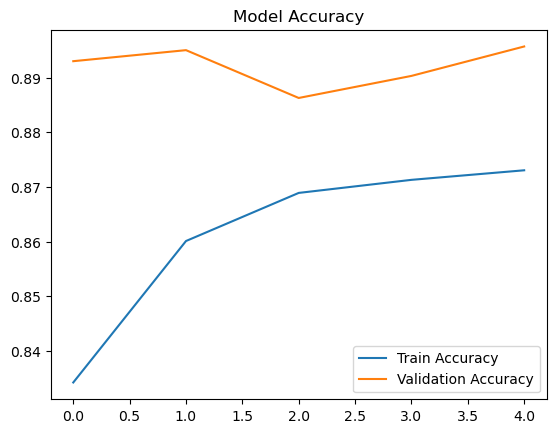

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Model Accuracy")
plt.show()

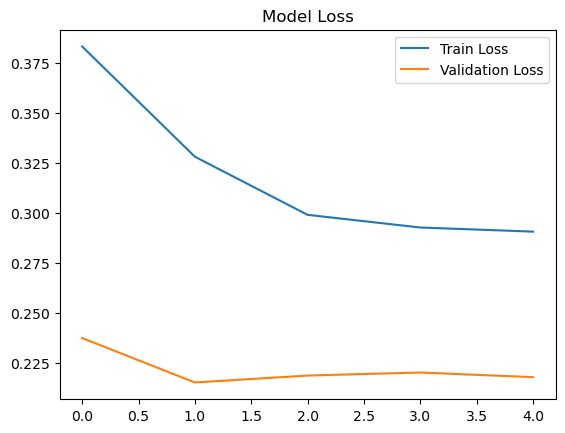

In [23]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Model Loss")
plt.show()

In [24]:
images_batch, labels_batch = next(data_test)

predictions = model.predict(images_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


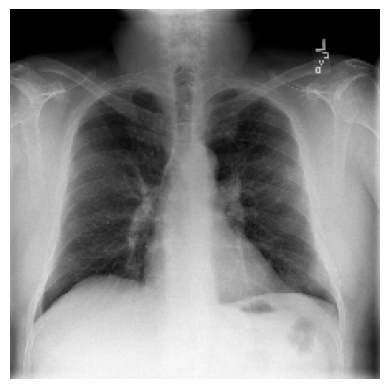

Actual: Normal
Predicted: Normal 0.35%


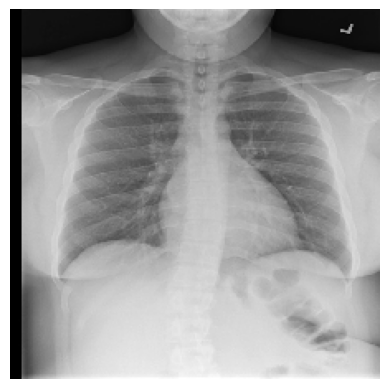

Actual: Normal
Predicted: Normal 0.37%


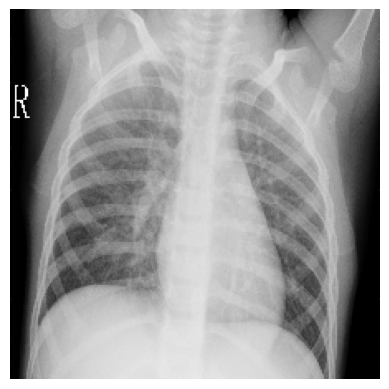

Actual: Pneumonia
Predicted: Pneumonia 76.68%


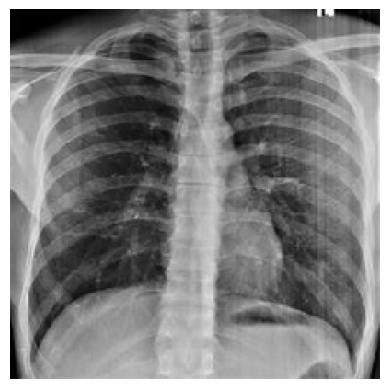

Actual: Normal
Predicted: Normal 16.09%


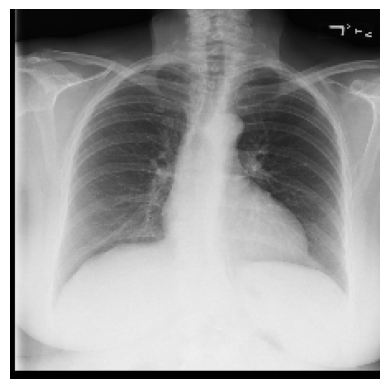

Actual: Normal
Predicted: Normal 0.27%


In [25]:
for j in range(5):

    plt.imshow(images_batch[j])
    plt.axis("off")
    plt.show()

    prob = predictions[j][0]

    pred_label = "Pneumonia" if prob >= 0.5 else "Normal"

    print("Actual:", "Pneumonia" if labels_batch[j]==1 else "Normal")
    print("Predicted:", pred_label, f"{prob*100:.2f}%")

In [26]:
from tensorflow.keras.preprocessing import image
import random

In [27]:
test_folder = "./chest_xray/test/NORMAL/"

random_file = random.choice(os.listdir(test_folder))
img_path = os.path.join(test_folder, random_file)

In [28]:
img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [29]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


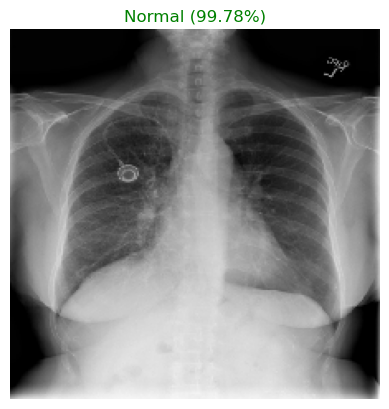

In [30]:
plt.imshow(img)
plt.axis("off")

if prediction[0][0] >= 0.5:
    plt.title(f"Pneumonia ({prediction[0][0]*100:.2f}%)", color="red")
else:
    plt.title(f"Normal ({(1-prediction[0][0])*100:.2f}%)", color="green")

plt.show()

In [31]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [32]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

In [33]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name="conv5_block16_concat"
)

c:\Anaconda\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


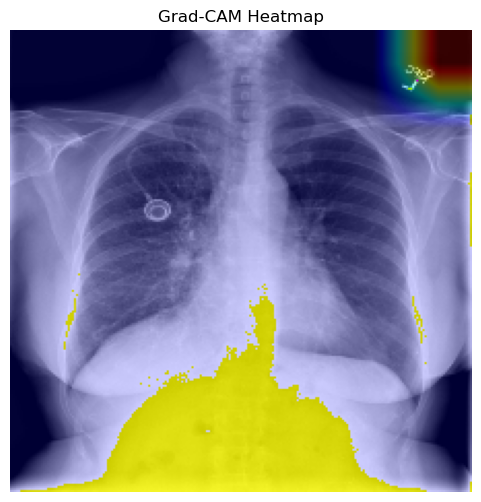

In [34]:
img = cv2.imread(img_path)
img = cv2.resize(img,(224,224))

heatmap = cv2.resize(heatmap,(224,224))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Heatmap")
plt.show()

In [35]:
model.save('cnn_latest_model.keras')